In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')
# ----------------------------------------------------------------------------
# 1. Load Data
# ----------------------------------------------------------------------------
try:
    df = pd.read_csv('hand_gesture_clean_labeled.csv')
    print("Dataset Loaded Successfully.")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Error: 'hand_gesture_clean_labeled.csv' not found. Please upload it.")
    raise

# ----------------------------------------------------------------------------
# 2. Feature & Target Preparation
# ----------------------------------------------------------------------------
# Extract distance features
dist_cols = [c for c in df.columns if c.startswith("dist_")]
X = df[dist_cols]

# Target: Gesture Label (Adjust to 0-4 range for XGBoost if needed)
# Assuming labels in CSV are 1-5 or 0-4.
if df['gesture_label'].min() == 1:
    y = df['gesture_label'] - 1
else:
    y = df['gesture_label']

# Groups: Person ID (Critical for cross-validation)
groups = df['person_id']

print(f"Features: {len(dist_cols)}")
print(f"Classes: {y.unique()}")
print(f"Total People: {df['person_id'].nunique()}")

# ----------------------------------------------------------------------------
# 3. Model Definition
# ----------------------------------------------------------------------------
# Define XGBoost separately to configure it correctly
xgb_model = XGBClassifier(
    n_estimators=200, 
    learning_rate=0.1, 
    max_depth=6, 
    objective='multi:softprob', 
    num_class=5, 
    eval_metric='mlogloss', 
    random_state=42, 
    verbosity=0
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "XGBoost": xgb_model
}

# Helper to check leakage
def check_leakage(train_idx, test_idx, groups):
    train_groups = set(groups.iloc[train_idx])
    test_groups = set(groups.iloc[test_idx])
    overlap = train_groups.intersection(test_groups)
    return len(overlap) > 0

Dataset Loaded Successfully.
Shape: (5226, 214)
Features: 210
Classes: [1 3 2 4 0]
Total People: 102


In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler

ratios = [0.5, 0.6, 0.7, 0.8]
metrics_exp1 = []

for ratio in ratios:
    train_pct = int(ratio * 100)
    test_pct = 100 - train_pct
    
    gss = GroupShuffleSplit(n_splits=5, train_size=ratio, random_state=42)

    for train_idx, test_idx in gss.split(X, y, groups):

        # Split
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Scaling
        std_scaler = StandardScaler().fit(X_train)
        mm_scaler  = MinMaxScaler().fit(X_train)

        for name, model in models.items():

            if name in ["Logistic Regression", "SVM", "KNN"]:
                X_tr = std_scaler.transform(X_train)
                X_te = std_scaler.transform(X_test)
            else:
                X_tr = mm_scaler.transform(X_train)
                X_te = mm_scaler.transform(X_test)

            model.fit(X_tr, y_train)
            preds = model.predict(X_te)

            metrics_exp1.append([
                f"{train_pct}-{test_pct}",
                name,
                accuracy_score(y_test, preds),
                precision_score(y_test, preds, average="weighted"),
                recall_score(y_test, preds, average="weighted"),
                f1_score(y_test, preds, average="weighted")
            ])

df_metrics = pd.DataFrame(
    metrics_exp1,
    columns=["Split", "Model", "Accuracy", "Precision", "Recall", "F1"]
)


In [ ]:
final_table = (
    df_metrics
    .groupby(["Split", "Model"])
    .mean()
    .round(3)
    .reset_index()
)

final_table

,Split,Model,Accuracy,Precision,Recall,F1
0,50-50,Decision Tree,0.892,0.895,0.892,0.892
1,50-50,KNN,0.940,0.941,0.940,0.940
2,50-50,Logistic Regression,0.971,0.971,0.971,0.971
3,50-50,Naive Bayes,0.786,0.819,0.786,0.782
4,50-50,Random Forest,0.933,0.935,0.933,0.933
5,50-50,SVM,0.963,0.964,0.963,0.963
6,50-50,XGBoost,0.932,0.933,0.932,0.932
7,60-40,Decision Tree,0.879,0.882,0.879,0.879
8,60-40,KNN,0.938,0.941,0.938,0.938
9,60-40,Logistic Regression,0.968,0.968,0.968,0.968


In [7]:
final_table = final_table.sort_values(by="Accuracy", ascending=False)
final_table

,Split,Model,Accuracy,Precision,Recall,F1
26,80-20,SVM,0.976,0.976,0.976,0.976
2,50-50,Logistic Regression,0.971,0.971,0.971,0.971
23,80-20,Logistic Regression,0.970,0.971,0.970,0.970
16,70-30,Logistic Regression,0.969,0.969,0.969,0.969
9,60-40,Logistic Regression,0.968,0.968,0.968,0.968
19,70-30,SVM,0.967,0.968,0.967,0.967
5,50-50,SVM,0.963,0.964,0.963,0.963
12,60-40,SVM,0.963,0.963,0.963,0.963
22,80-20,KNN,0.947,0.949,0.947,0.947
15,70-30,KNN,0.945,0.947,0.945,0.945


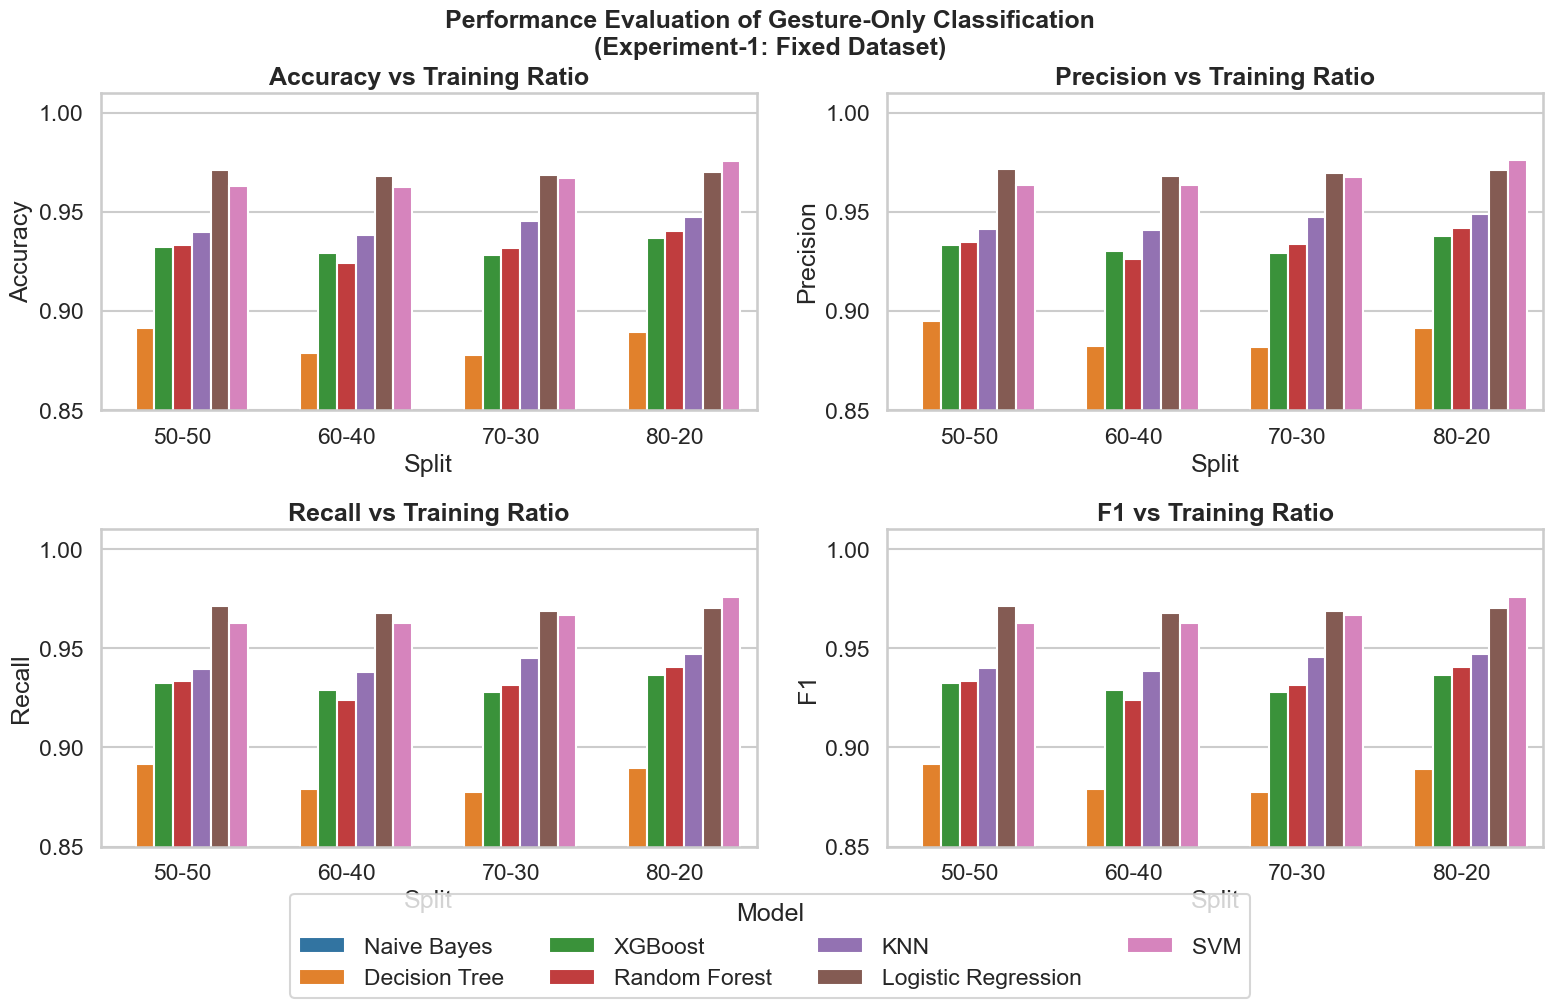

In [ ]:
sns.set_theme(style="whitegrid", context="talk")

metrics = ["Accuracy", "Precision", "Recall", "F1"]
model_order = [
    "Naive Bayes",
    "Decision Tree",
    "XGBoost",
    "Random Forest",
    "KNN",
    "Logistic Regression",
    "SVM"
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_metrics,
        x="Split",
        y=metric,
        hue="Model",
        hue_order=model_order,
        errorbar=None,
        palette="tab10",
        ax=axes[i]
    )
    axes[i].set_title(f"{metric} vs Training Ratio", fontweight="bold")
    axes[i].set_ylim(0.85, 1.01)
    axes[i].legend_.remove()

# Common legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    title="Model",
    bbox_to_anchor=(0.5, -0.02)
)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])


plt.suptitle(
    "Performance Evaluation of Gesture-Only Classification\n(Experiment-1: Fixed Dataset)",
    fontsize=18,
    fontweight="bold"
)

plt.show()

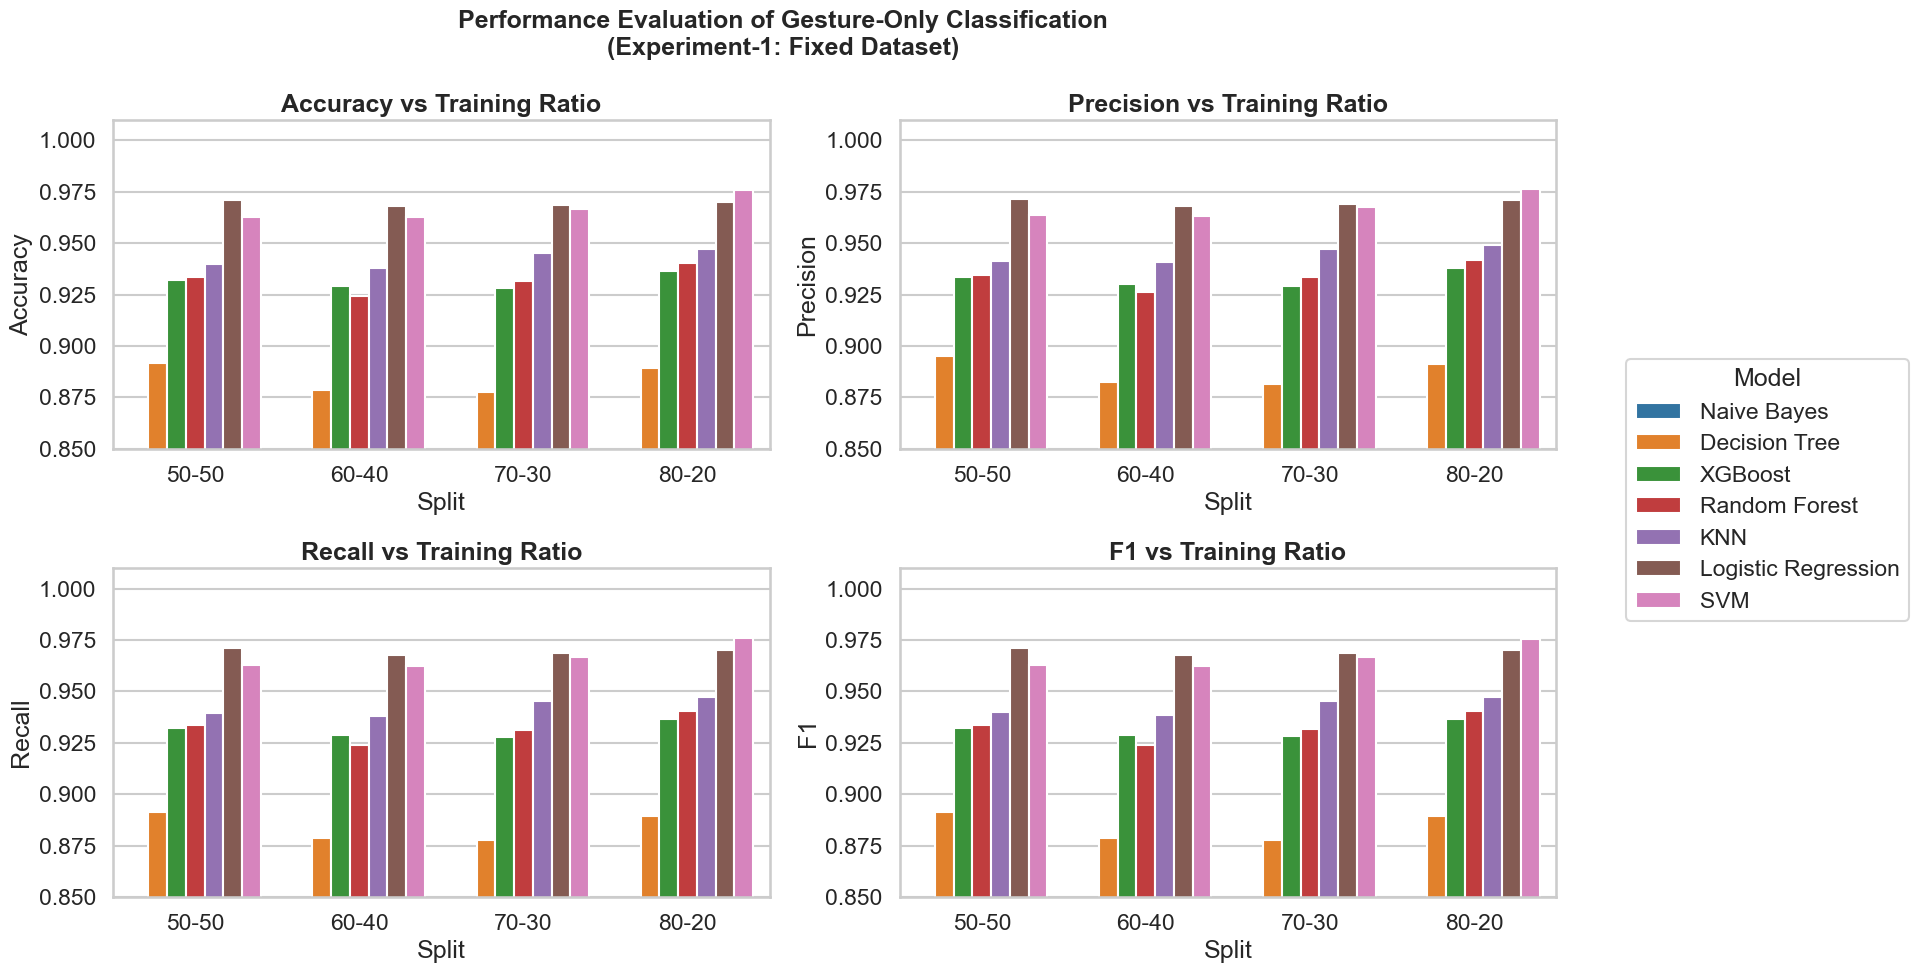

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="talk")

metrics = ["Accuracy", "Precision", "Recall", "F1"]

model_order = [
    "Naive Bayes",
    "Decision Tree",
    "XGBoost",
    "Random Forest",
    "KNN",
    "Logistic Regression",
    "SVM"
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_metrics,
        x="Split",
        y=metric,
        hue="Model",
        hue_order=model_order,
        errorbar=None,
        palette="tab10",
        ax=axes[i]
    )
    axes[i].set_title(f"{metric} vs Training Ratio", fontweight="bold")
    axes[i].set_ylim(0.85, 1.01)
    axes[i].legend_.remove()  # remove individual legends

# ---- Common legend (outside, clean) ----
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Model",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

plt.suptitle(
    "Performance Evaluation of Gesture-Only Classification\n"
    "(Experiment-1: Fixed Dataset)",
    fontsize=18,
    fontweight="bold"
)

# Leave space on the right for legend
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

<Figure size 640x480 with 0 Axes>

In [ ]:
# Average over 5-fold CV
heatmap_data = (
    df_metrics
    .groupby(["Split", "Model"])
    .mean()
    .reset_index()
)

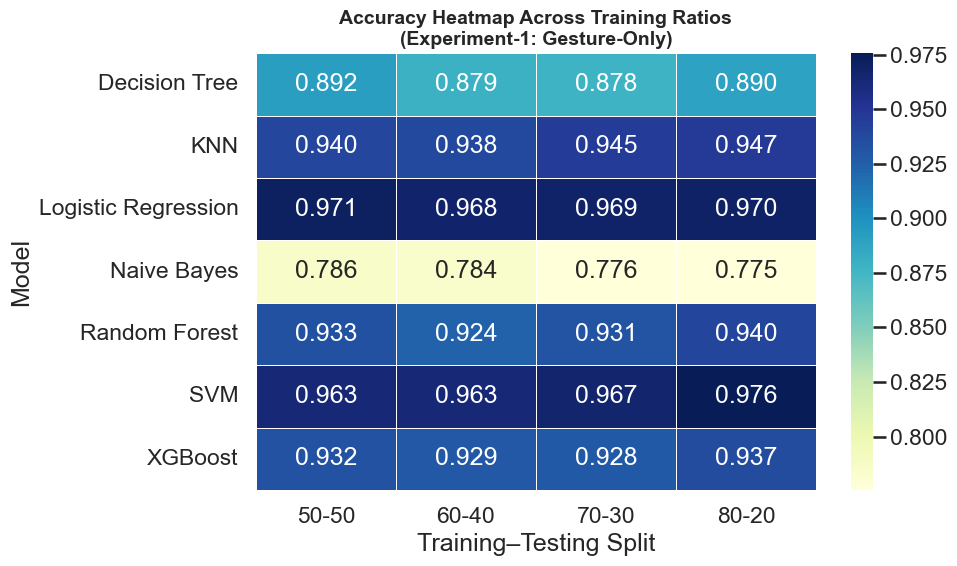

In [ ]:
plt.figure(figsize=(10, 6))

acc_matrix = heatmap_data.pivot(
    index="Model",
    columns="Split",
    values="Accuracy"
)

sns.heatmap(
    acc_matrix,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title(
    "Accuracy Heatmap Across Training Ratios\n(Experiment-1: Gesture-Only)",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Training–Testing Split")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

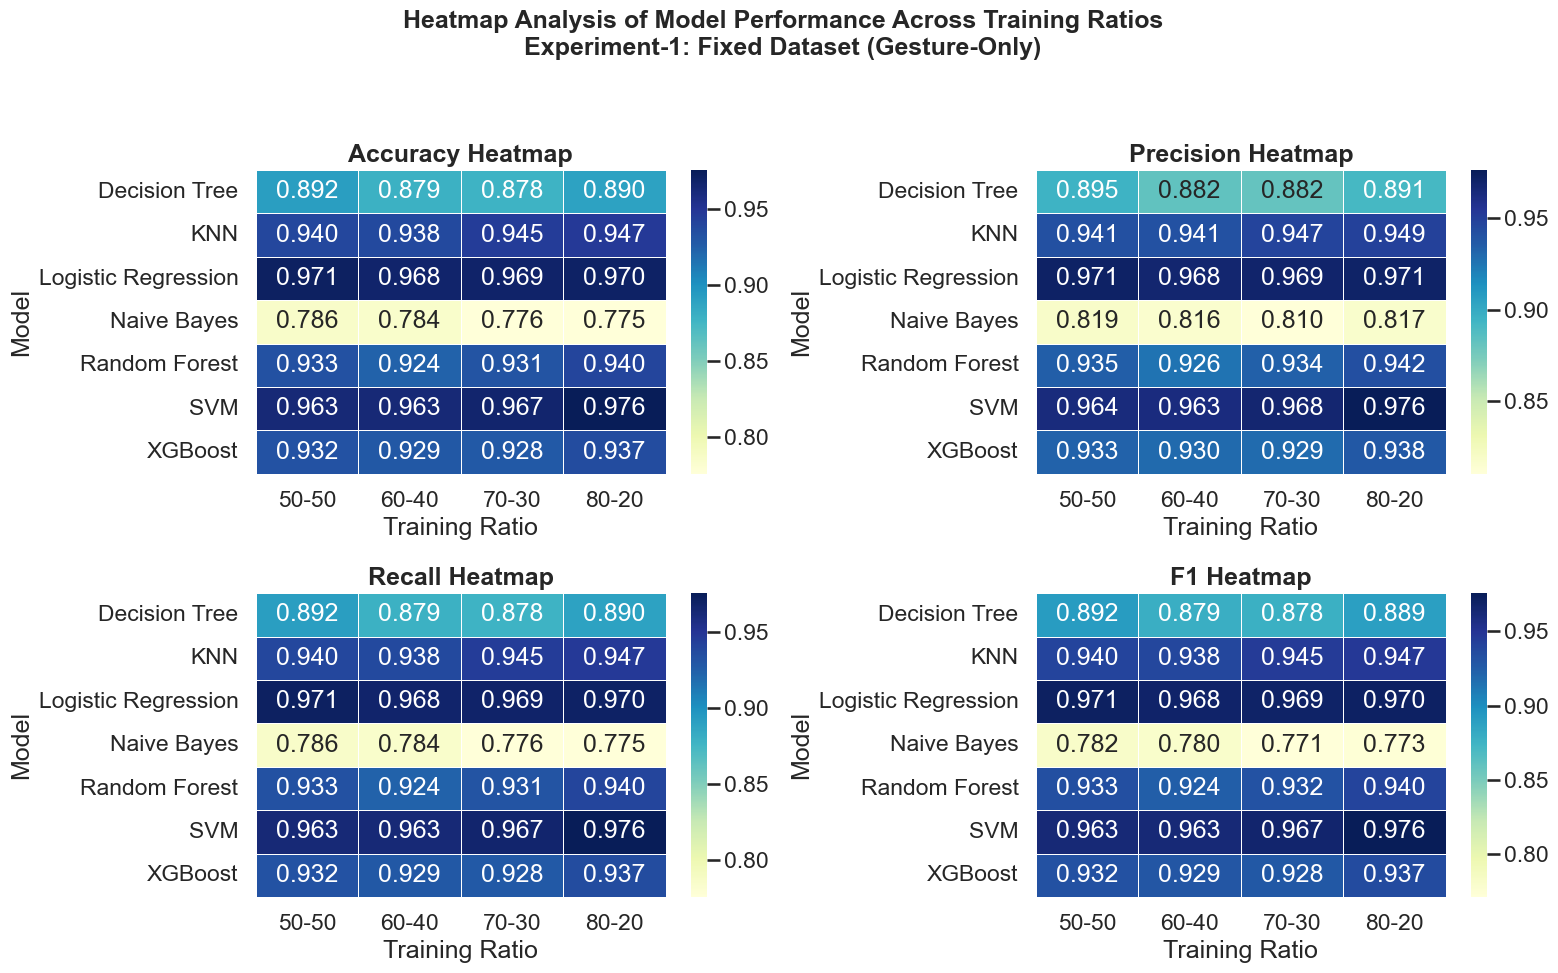

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):

    metric_matrix = heatmap_data.pivot(
        index="Model",
        columns="Split",
        values=metric
    )

    sns.heatmap(
        metric_matrix,
        annot=True,
        fmt=".3f",
        cmap="YlGnBu",
        linewidths=0.5,
        ax=axes[i]
    )

    axes[i].set_title(f"{metric} Heatmap", fontweight="bold")
    axes[i].set_xlabel("Training Ratio")
    axes[i].set_ylabel("Model")

plt.suptitle(
    "Heatmap Analysis of Model Performance Across Training Ratios\n"
    "Experiment-1: Fixed Dataset (Gesture-Only)",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 🧪 EXPERIMENT–2 Variation of Data Size with Fixed Training Ratio (80–20)

In [29]:
data_sizes = [0.4, 0.6, 0.8, 1.0]
results_exp2 = []

for size in data_sizes:
    print(f"\nProcessing Data Size: {int(size*100)}%")

    # Sample data while preserving class distribution
    df_sampled = df.groupby("gesture_label", group_keys=False)\
                    .apply(lambda x: x.sample(frac=size, random_state=42))

    X_ds = df_sampled[dist_cols]
    y_ds = df_sampled["gesture_label"] - 1 if df_sampled["gesture_label"].min() == 1 else df_sampled["gesture_label"]
    groups_ds = df_sampled["person_id"]

    gss = GroupShuffleSplit(n_splits=5, train_size=0.8, random_state=42)

    for train_idx, test_idx in gss.split(X_ds, y_ds, groups_ds):

        X_train, X_test = X_ds.iloc[train_idx], X_ds.iloc[test_idx]
        y_train, y_test = y_ds.iloc[train_idx], y_ds.iloc[test_idx]

        std_scaler = StandardScaler().fit(X_train)
        mm_scaler = MinMaxScaler().fit(X_train)

        for name, model in models.items():

            if name in ["Logistic Regression", "SVM", "KNN"]:
                X_tr = std_scaler.transform(X_train)
                X_te = std_scaler.transform(X_test)
            else:
                X_tr = mm_scaler.transform(X_train)
                X_te = mm_scaler.transform(X_test)

            model.fit(X_tr, y_train)
            preds = model.predict(X_te)

            results_exp2.append([
                f"{int(size*100)}%",
                name,
                accuracy_score(y_test, preds),
                precision_score(y_test, preds, average="weighted"),
                recall_score(y_test, preds, average="weighted"),
                f1_score(y_test, preds, average="weighted")
            ])



Processing Data Size: 40%

Processing Data Size: 60%

Processing Data Size: 80%

Processing Data Size: 100%


In [30]:
df_exp2 = pd.DataFrame(
    results_exp2,
    columns=["Data_Size", "Model", "Accuracy", "Precision", "Recall", "F1"]
)


In [31]:
acc_table = df_exp2.groupby(["Data_Size", "Model"])["Accuracy"].mean().unstack().round(3)
acc_table


Model,Decision Tree,KNN,Logistic Regression,Naive Bayes,Random Forest,SVM,XGBoost
Data_Size,,,,,,,
100%,0.890,0.947,0.970,0.775,0.937,0.976,0.937
40%,0.882,0.935,0.973,0.771,0.930,0.971,0.930
60%,0.887,0.948,0.974,0.780,0.933,0.972,0.929
80%,0.896,0.947,0.971,0.770,0.932,0.973,0.932


In [32]:
prec_table = df_exp2.groupby(["Data_Size", "Model"])["Precision"].mean().unstack().round(3)
prec_table


Model,Decision Tree,KNN,Logistic Regression,Naive Bayes,Random Forest,SVM,XGBoost
Data_Size,,,,,,,
100%,0.891,0.949,0.971,0.817,0.939,0.976,0.938
40%,0.886,0.939,0.973,0.808,0.932,0.972,0.932
60%,0.892,0.951,0.975,0.816,0.935,0.973,0.931
80%,0.899,0.949,0.971,0.811,0.935,0.974,0.933


In [33]:
f1_table = df_exp2.groupby(["Data_Size", "Model"])["F1"].mean().unstack().round(3)
f1_table


Model,Decision Tree,KNN,Logistic Regression,Naive Bayes,Random Forest,SVM,XGBoost
Data_Size,,,,,,,
100%,0.889,0.947,0.970,0.773,0.937,0.976,0.937
40%,0.881,0.936,0.973,0.766,0.930,0.971,0.930
60%,0.886,0.948,0.974,0.776,0.933,0.972,0.929
80%,0.896,0.947,0.971,0.768,0.932,0.973,0.932


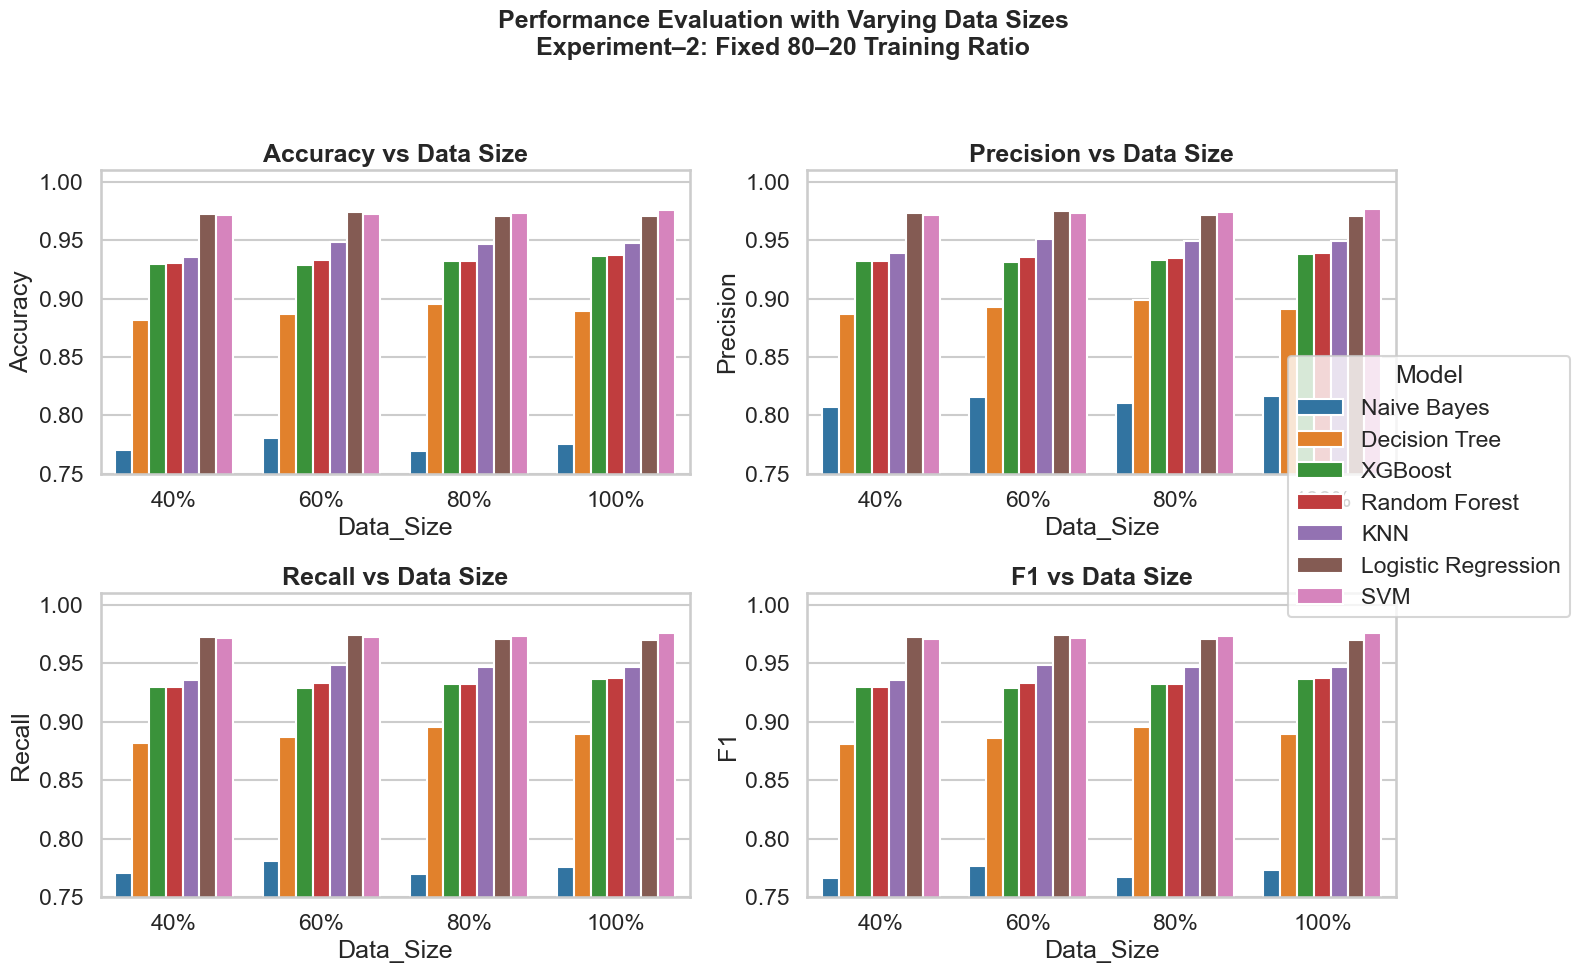

In [ ]:
sns.set_theme(style="whitegrid", context="talk")

metrics = ["Accuracy", "Precision", "Recall", "F1"]
model_order = [
    "Naive Bayes",
    "Decision Tree",
    "XGBoost",
    "Random Forest",
    "KNN",
    "Logistic Regression",
    "SVM"
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.barplot(
        data=df_exp2,
        x="Data_Size",
        y=metric,
        hue="Model",
        hue_order=model_order,
        errorbar=None,
        palette="tab10",
        ax=axes[i]
    )
    axes[i].set_title(f"{metric} vs Data Size", fontweight="bold")
    axes[i].set_ylim(0.75, 1.01)
    axes[i].legend_.remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center right", title="Model")

plt.suptitle(
    "Performance Evaluation with Varying Data Sizes\n"
    "Experiment–2: Fixed 80–20 Training Ratio",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()

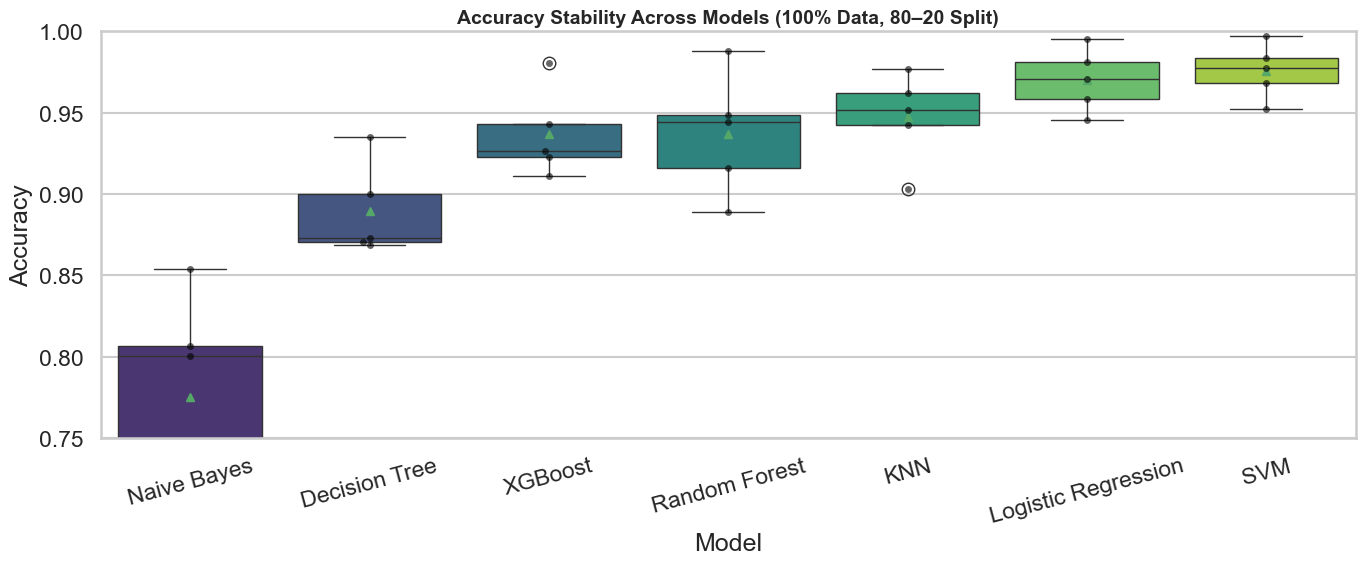

In [ ]:
plt.figure(figsize=(14, 6))

subset_100 = df_exp2[df_exp2["Data_Size"] == "100%"]

sns.boxplot(
    x="Model",
    y="Accuracy",
    data=subset_100,
    order=model_order,
    showmeans=True,
    palette="viridis"
)

sns.swarmplot(
    x="Model",
    y="Accuracy",
    data=subset_100,
    order=model_order,
    color="black",
    alpha=0.6
)

plt.title("Accuracy Stability Across Models (100% Data, 80–20 Split)",
          fontsize=14, fontweight="bold")
plt.xticks(rotation=15)
plt.ylim(0.75, 1.0)
plt.tight_layout()
plt.show()